In [1]:
from uspas_llrf import LLRFApp
from pprint import pprint
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

# LLRF demo for USPAS setting

## Setup clock input

Here is an example at LBNL to set the external clock and MO signals:

In [ ]:
from uspas_llrf.tools.erasynth_micro import EraSynthMicro

# Clock to Zest
with EraSynthMicro(port='/dev/ttyACM1') as era_synth_clk:
    era_synth_clk.read_temperature()
    era_synth_clk.set_frequency(460e6)
    era_synth_clk.set_amplitude(0)

# PRL at ADC0 at IF_adc
# with EraSynthMicro(port='/dev/ttyACM1') as era_synth_prl:
#     era_synth_prl.read_temperature()
#     era_synth_prl.set_frequency(20e6)
#     era_synth_prl.set_amplitude(10)

Read  Temperature [C]: 43.3750
Wrote Frequency [MHz]: 460.0
Wrote Amplitude [dBm]: 0
Read  Temperature [C]: 44.1250
Wrote Frequency [MHz]: 20.0
Wrote Amplitude [dBm]: 10


# Program bitstream file

In [3]:
!make -C ../../top/marble_zest/ system_config MARBLE_SERIAL=42 BITSTREAM=marble_zest_top_USPAS.0aad7a43.bit

make: Entering directory '/home/qdu/work/uspas_llrf/top/marble_zest'
Makefile:41: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 42
openocd \
-c "adapter serial 000042;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_USPAS.0aad7a43.bit; exit"
Open On-Chip Debugger 0.12.0+dev-00519-gb6ee13720-dirty (2025-07-15-02:38)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Info : auto-selecting first available session transport "jtag". To override use 'transport select <transport>'.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] E

# Read Board Support info

In [7]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='USPAS', chan_keep=0b1011)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :     25.2 mV
  Power      :     22.8 mW
  Vbus       :     11.9 V
  Current    :  -1093.1 mA
INA219 U17, FMC1:
  Vshunt     :     29.4 mV
  Power      :     19.0 mW
  Vbus       :     11.8 V
  Current    :    187.1 mA
INA219 U32, FMC2:
  Vshunt     :    -17.9 mV
  Power      :      5.3 mW
  Vbus       :     11.8 V
  Current    :    135.2 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11110000
  Temp       :    50 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    668 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    690 uW
  TxBias2    :    0 uA
  TxPwr2     :  

## Measure a snapshot of RF amplitude and phases

Match LBNL test rack cables connections:
* DAC0 -> ADC1
* DAC1 -> ADC3
* MO -> ADC0

In [26]:
prl_adc_chan, loop0_adc_chan = 0, 1
llrf.reg_write([
    ('prl_adc_chan', prl_adc_chan),
    ('loop0_adc_chan', loop0_adc_chan),
])

LLRFApp.init_open_loop_demo() forces CW mode, and bypass all interlocks!

In [27]:
llrf.init_cw_demo()
llrf.init_loop('loop0', amp_setp_adc=2e4)
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,12367,-14,33784.624317,-0.038452
adc1,3821,-26252,10438.347984,-72.103271
adc2,2,-49138,5.463673,-134.961548
adc3,3666,-49656,10014.913297,-136.384277
adc4,2,-65226,5.463673,-179.148560
adc5,2,-49138,5.463673,-134.961548
adc6,2,-32458,5.463673,-89.148560
adc7,2,36366,5.463673,99.882202
drv0,4523,22801,19996.533554,0.016121
drv1,6784,22797,29992.589792,0.005135


Confirm MO phase is aligned

In [28]:
assert -0.2 < df_mon['Phs [deg]'][f'adc{prl_adc_chan}'] < 0.2

## Plot raw DAC / ADC data

In [29]:
loop0_adc = f'adc{loop0_adc_chan}'
df_sig = llrf.get_raw_bufs_df()

ADC1 max: -9.937 dBFS at 19.980 MHz
ADC3 max: -10.304 dBFS at 19.980 MHz


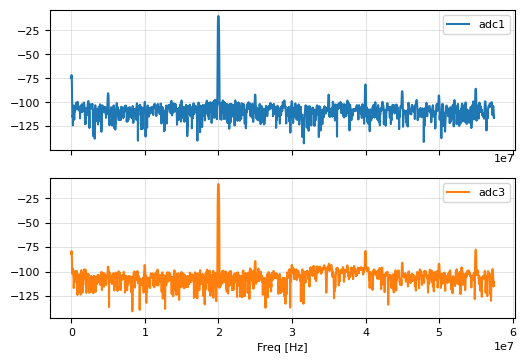

In [30]:
cols = [loop0_adc, 'adc3']
df_psd = llrf.calc_psd_df(df_sig)
df_psd[cols].plot(subplots=True);
print(f'ADC1 max: {df_psd.adc1.max():.3f} dBFS at {df_psd.adc1.idxmax()/1e6:.3f} MHz')
print(f'ADC3 max: {df_psd.adc3.max():.3f} dBFS at {df_psd.adc3.idxmax()/1e6:.3f} MHz')

# Pulse mode test

`dac_drive_sel` for USPAS is 0, therefore both DACs are controlled by loop0!

In [31]:
# generate 4µs pulse
fs = llrf.fs / 1e9
start0 = 50
length0 = int(4000 * fs)
llrf.reg_write([
    ('loop0_pulse_start', start0),
    ('loop0_pulse_high_len', length0),
    ('pulse_modes', 0b1)
])

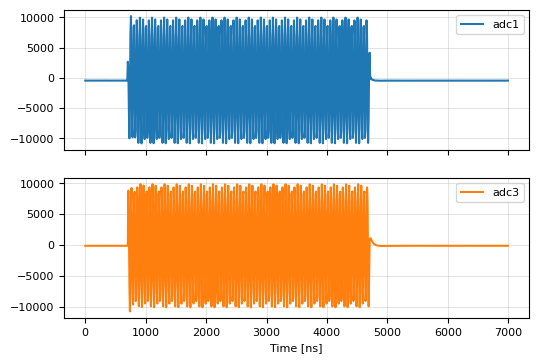

In [32]:
len_ns = 7000
df_sig = llrf.get_raw_bufs_df()
df_sig[[loop0_adc, 'adc3']].loc[:len_ns].plot(subplots=True);

Get base band IQ waveforms

In [33]:
df_iq = llrf.get_iq_wfms_df()

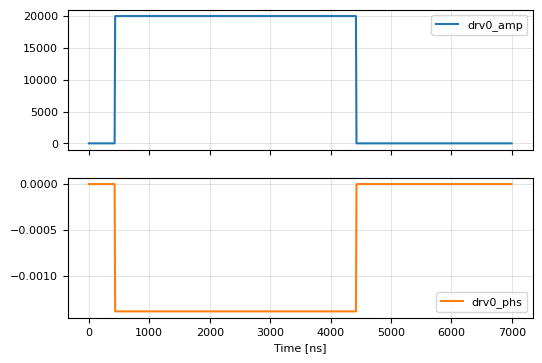

In [34]:
df_iq[['drv0_amp', 'drv0_phs']].loc[:len_ns].plot(subplots=True);

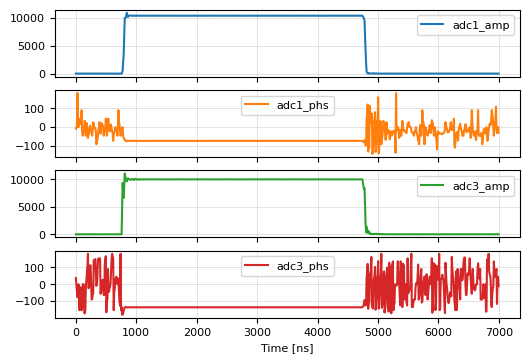

In [35]:
cols = [
    loop0_adc+'_amp', loop0_adc+'_phs',
    'adc3_amp', 'adc3_phs'
]
df_iq[cols].loc[:len_ns].plot(subplots=True);

Verify IQ waveform signal gain:

In [36]:

amp = df_iq[[loop0_adc + '_amp']].loc[500:4000].values.mean()
phs = df_iq[[loop0_adc + '_phs']].loc[500:4000].values.mean()
print(f'fdbk_adc IQ waveform signal: amp = {amp:8.3f} cnt, phs = {phs:8.3f} deg')

amp_exp = df_mon['Amp [cnt]'][loop0_adc]
phs_exp = df_mon['Phs [deg]'][loop0_adc]
print(f'fdbk_adc expected inlk_mon:  amp = {amp_exp:8.3f} cnt, '
      f'phs = {phs_exp:8.3f} deg')

fdbk_adc IQ waveform signal: amp = 9557.839 cnt, phs =  -66.937 deg
fdbk_adc expected inlk_mon:  amp = 10438.348 cnt, phs =  -72.103 deg


## Plot CIC circular buffer data

In [37]:
df_mp = llrf.get_cic_wfm_df()

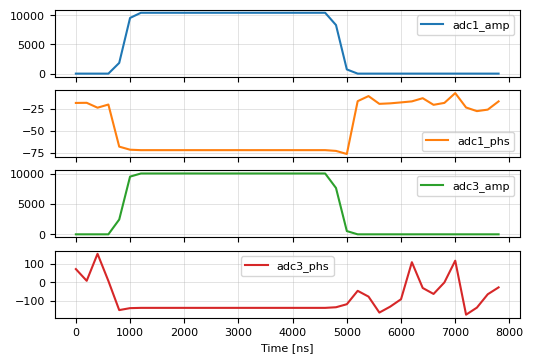

In [38]:
len_ns = 8000
df_mp[cols].loc[:len_ns].plot(subplots=True);